In [173]:
#Construir Modelos de Aprendizado Maquina
#Entrega Fase Final 2
#Aluno: Helder de Oliveira Barros

#Importar BiBliotecas
import pandas as pd

import numpy as np

import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [174]:
#Carregar Arquivo
df = pd.read_csv("dataImobiliarioSaoPaulo.csv")

df.head()

,address,district,area,bedrooms,garage,type,rent,total
0,Rua Herval,Belenzinho,21,1,0,Studio e kitnet,2400,2939
1,Avenida São Miguel,Vila Marieta,15,1,1,Studio e kitnet,1030,1345
2,Rua Oscar Freire,Pinheiros,18,1,0,Apartamento,4000,4661
3,Rua Júlio Sayago,Vila Ré,56,2,2,Casa em condomínio,1750,1954
4,Rua Barata Ribeiro,Bela Vista,19,1,0,Studio e kitnet,4000,4654


In [175]:
#Conhecimento de Dados
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11657 entries, 0 to 11656
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   address   11657 non-null  object
 1   district  11657 non-null  object
 2   area      11657 non-null  int64 
 3   bedrooms  11657 non-null  int64 
 4   garage    11657 non-null  int64 
 5   type      11657 non-null  object
 6   rent      11657 non-null  int64 
 7   total     11657 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 728.7+ KB


address     0
district    0
area        0
bedrooms    0
garage      0
type        0
rent        0
total       0
dtype: int64

In [176]:
#Limpar Dados
df = df.dropna()

In [177]:
#Escolher Variaveis
X = df[[
    "area",
    "bedrooms",
    "garage",
    "total"
]]

y = df["rent"]

In [178]:
#Dividir Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [179]:
#Treinar Modelo
modelo = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, n_estimators=50,
                      n_jobs=-1, random_state=42)

In [180]:
#Previsões
y_pred = modelo.predict(X_test)

In [181]:
#Avaliar Métricas
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 279.66
MSE : 231454.49
RMSE: 481.10
R²  : 0.9672


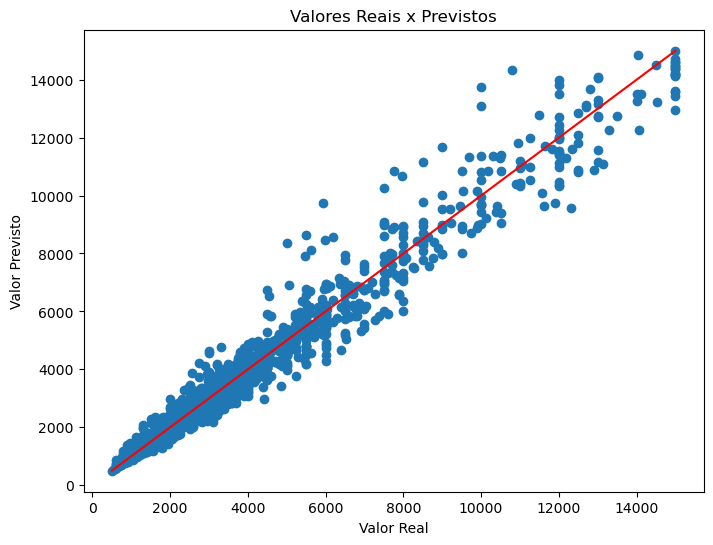

In [182]:
#Gráfico
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais x Previstos")

plt.show()

In [183]:
#Salvar Modelo
joblib.dump(
    modelo,
    "modelo_imoveis.pkl",
    compress=3
)

print("Modelo salvo!")

Modelo salvo!


In [184]:
import os

tamanho = os.path.getsize("modelo_imoveis.pkl")/(1024*1024)

print(f"Tamanho: {tamanho:.2f} MB")

Tamanho: 3.05 MB
